# **IAPR26: UNO Vision Challenge**


**Group Name :** 

**Author 1 :** Arno Douady (326395)  
**Author 2 :** Nicolas Robson (325334)   
**Author 3 :** Johanne Pinel (324707)   

**Release date:** 24.04.2026   
**Due date:** 20.05.2026 (11:55 pm)


In [ ]:

from src.Project_plots import *
from src.Project_segmentation import *

import matplotlib.image as mpimg
import os


from src.Project_cards_detection import *

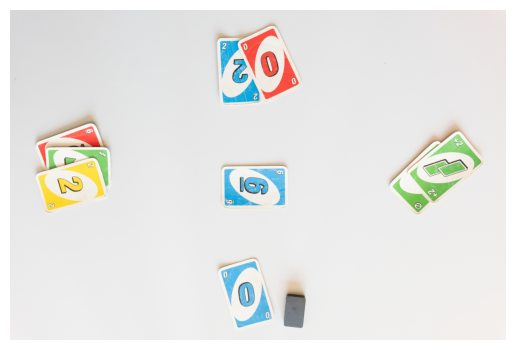

## Second step : Detection

The second step, detection, 

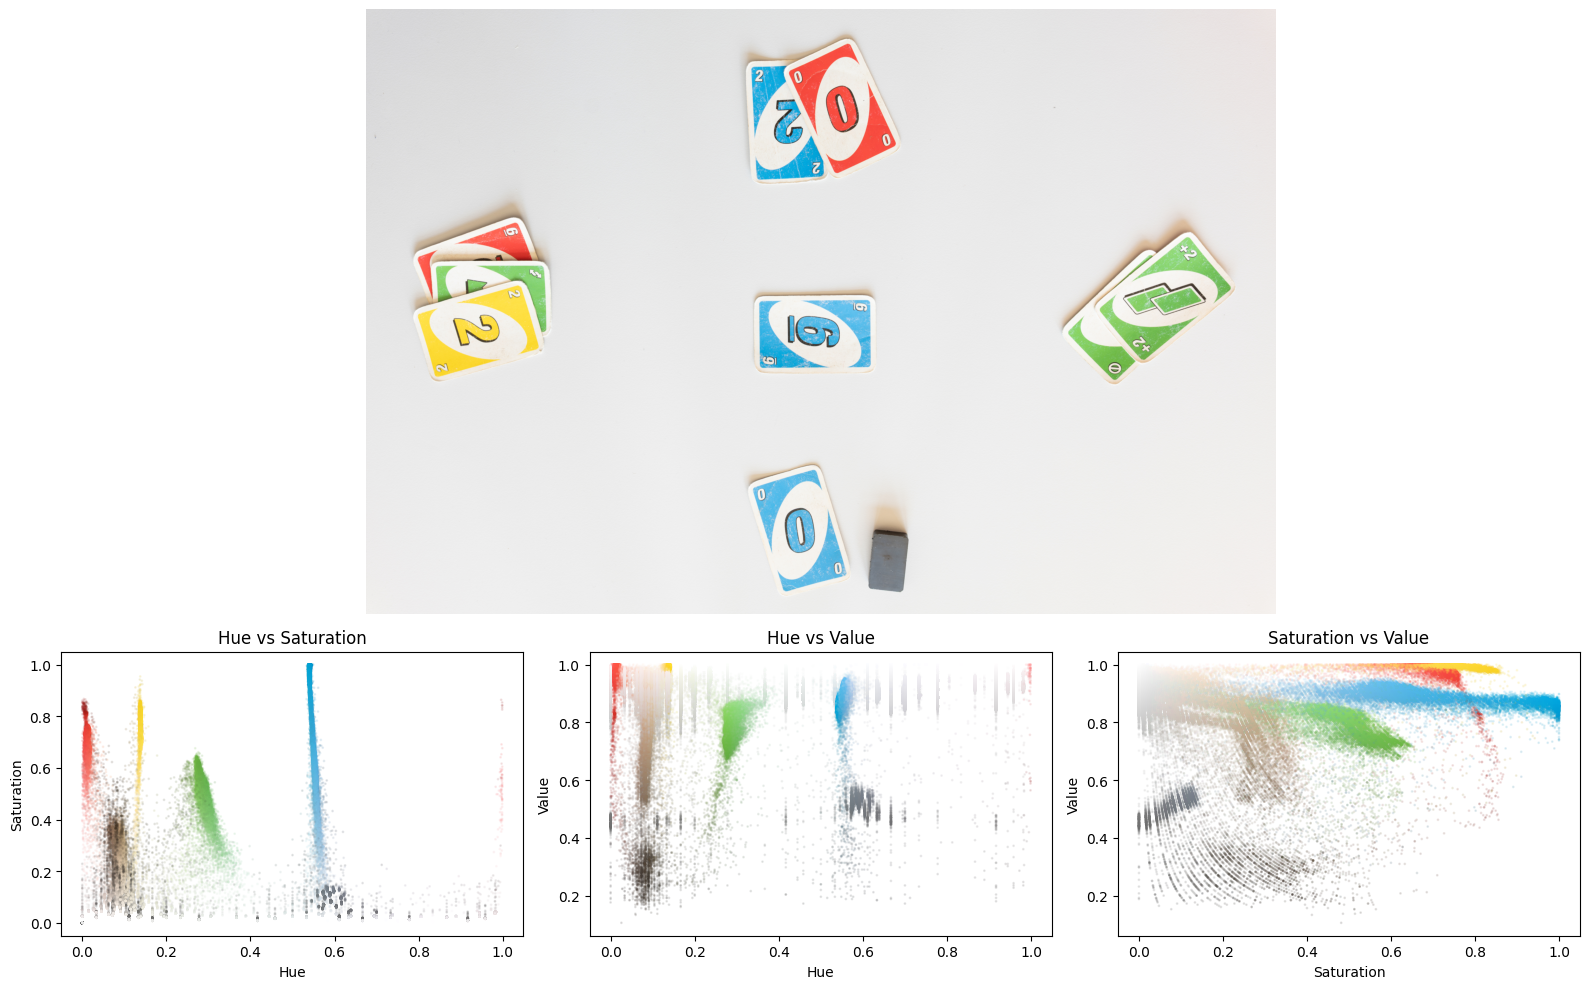

In [7]:
plot_colors_histo(
    img = img,
    func = extract_hsv_channels,
    labels = ["Hue", "Saturation", "Value"],
)
# warning : long à run, environ 1min20s

We use the HSV color space instead of RGB because it provides a more robust representation for color-based segmentation under real-world imaging conditions. In RGB, color information is tightly coupled with illumination, meaning that changes in lighting intensity directly affect all three channels, making thresholding unstable. In contrast, HSV separates chromatic content (Hue) from brightness (Value) and color saturation (Saturation). This decoupling allows us to define more consistent and interpretable thresholds for each card color, even when illumination varies across the scene. As a result, HSV enables more reliable and selective segmentation of UNO cards based on their dominant colors, improving the overall robustness of the detection pipeline.

We validated the choice of the HSV color space by comparing the color distributions in RGB and HSV using histograms. The RGB histograms show significant overlap between color channels and strong sensitivity to illumination changes, making it difficult to separate card colors using simple thresholds. In contrast, the HSV histograms exhibit a clearer separation


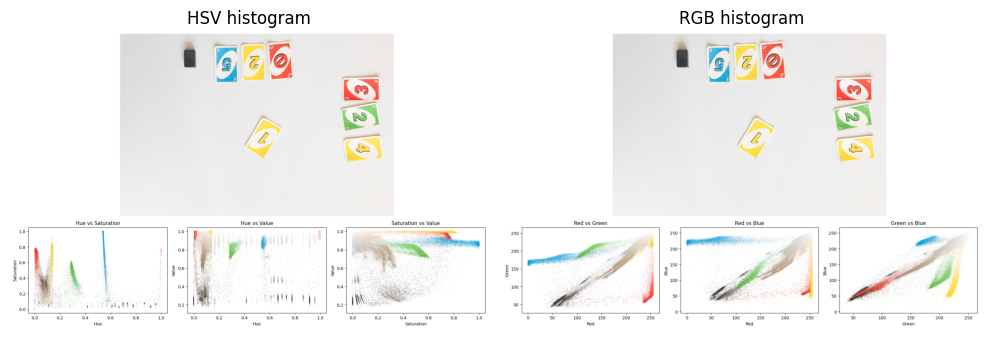

In [12]:
img1 = mpimg.imread("Rapport/output_HSV.png")
img2 = mpimg.imread("Rapport/output_RGB.png")

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img1)
axes[0].axis("off")
axes[0].set_title("HSV histogram")

axes[1].imshow(img2)
axes[1].axis("off")
axes[1].set_title("RGB histogram")

plt.tight_layout()
plt.show()

To improve mask quality, morphological operations are applied : closing is used to fill small holes inside detected regions.
Opening removes small noise artifacts. Small object removal filters out connected components below a minimum size threshold.

The size of the structuring element was chosen as a trade-off between noise removal and preservation of relevant card structures. A small structuring element would be insufficient to eliminate isolated pixels and small segmentation artifacts, while an excessively large one would distort or merge meaningful regions, potentially affecting card boundaries.

This results in clean binary masks for each color category

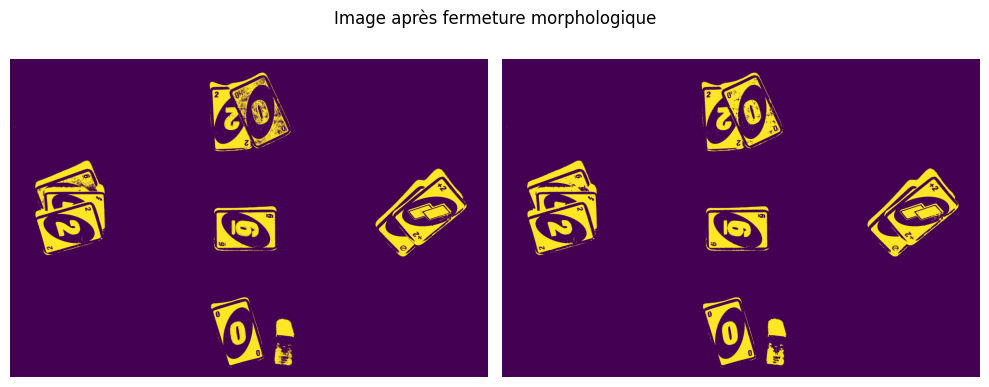

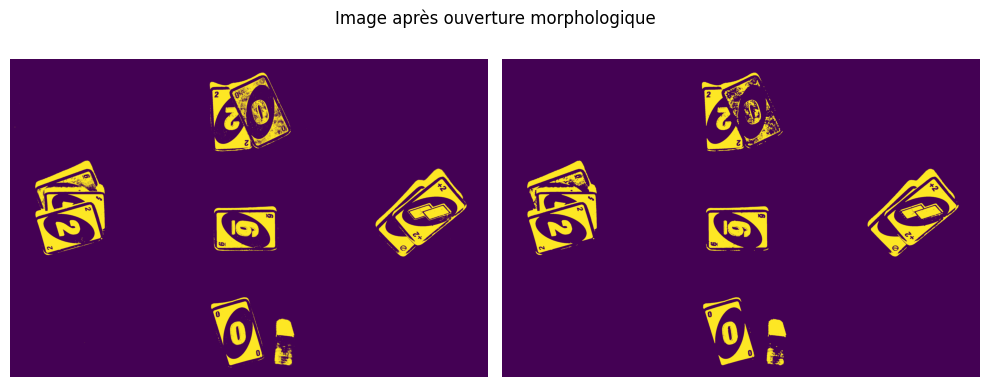

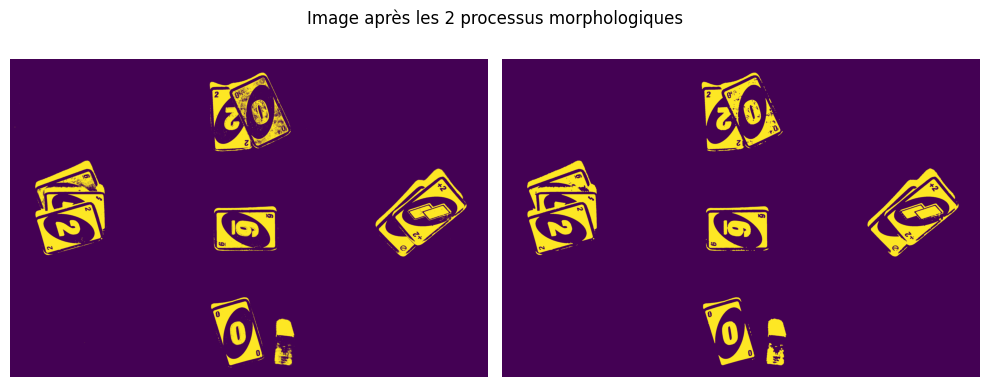

In [ ]:
img_th = apply_hsv_threshold(img)
#plot_close_open(img_th, apply_closing, apply_opening)

#img_closed = apply_closing(img_th, disk_size=2)
plot_thresholded_image(
    img_th,
    func=lambda x: apply_closing(x, disk_size=2),
    title="Image after closing"
)
#img_opened = apply_opening(img_th, disk_size=2)
plot_thresholded_image(
    img_th,
    func=lambda x: apply_opening(x, disk_size=2),
    title="Image after opening"
)

def apply_morpho (img):
    image = apply_closing(img, disk_size=2)
    image = apply_opening(image, disk_size=2)
    return image

plot_thresholded_image(
    img_th,
    func=lambda x: apply_morpho(x),
    title="Image after closing followed by opening"
)

For each target color (red, blue, green, yellow, and black), a dedicated thresholding function is applied to generate binary masks. These masks isolate regions in the image that correspond to potential UNO cards based on their dominant color.

This results in clean binary masks for each color category.

In [22]:
M, N, C= np.shape(img)
mask_red = np.zeros((M, N))
mask_blue = np.zeros((M, N))


mask_red = find_area_by_type(img, mode="red", visualize_mask=True)
mask_blue = find_area_by_type(img, mode="blue", visualize_mask=True)
mask_green = find_area_by_type(img, mode="green", visualize_mask=True)
mask_yellow = find_area_by_type(img, mode="yellow", visualize_mask=True)
mask_black = find_area_by_type(img, mode="black", visualize_mask=True)

c:\Users\Johanne\Desktop\EPFL\MA4\Image pattern\iapr2026\Project\src\Project_segmentation.py:148: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  out_mask = remove_small_objects(out_mask, min_size=object_min_size)


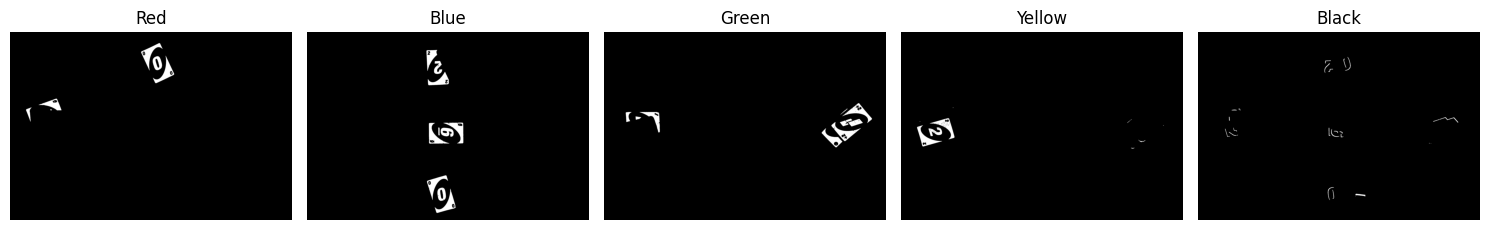

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

axes[0].imshow(mask_red, cmap='gray')
axes[0].set_title("Red")

axes[1].imshow(mask_blue, cmap='gray')
axes[1].set_title("Blue")

axes[2].imshow(mask_green, cmap='gray')
axes[2].set_title("Green")

axes[3].imshow(mask_yellow, cmap='gray')
axes[3].set_title("Yellow")

axes[4].imshow(mask_black, cmap='gray')
axes[4].set_title("Black")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()